In [212]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Database
import sqlite3

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [213]:
dataset_url = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

df = pd.read_csv(dataset_url)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 7043
Columns: 21


In [214]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Inspection

In [215]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null

In [216]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [217]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [218]:
blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()

print("Blank values in TotalCharges:", blank_total_charges)

Blank values in TotalCharges: 11


## 2. Data Cleaning

In [278]:
clean_df = df.copy()

In [220]:
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges values:")
print(clean_df["TotalCharges"].isnull().sum())

Missing TotalCharges values:
11


In [221]:
clean_df = clean_df.dropna(subset=["TotalCharges"]).copy()

print("Shape after removing missing values:", clean_df.shape)

Shape after removing missing values: (7032, 21)


In [222]:
clean_df["ChurnFlag"] = clean_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

clean_df[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [279]:
clean_df["SeniorCitizenLabel"] = clean_df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

In [280]:
clean_df["TenureGroup"] = pd.cut(
    clean_df["tenure"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "61-72 Months"
    ]
)

In [281]:
clean_df["MonthlyChargeGroup"] = pd.cut(
    clean_df["MonthlyCharges"],
    bins=[0, 35, 70, 100, float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    include_lowest=True
)

In [226]:
clean_df[
    [
        "customerID",
        "tenure",
        "TenureGroup",
        "MonthlyCharges",
        "MonthlyChargeGroup",
        "Churn"
    ]
].head()

,customerID,tenure,TenureGroup,MonthlyCharges,MonthlyChargeGroup,Churn
0,7590-VHVEG,1,0-12 Months,29.85,Low,No
1,5575-GNVDE,34,25-48 Months,56.95,Medium,No
2,3668-QPYBK,2,0-12 Months,53.85,Medium,Yes
3,7795-CFOCW,45,25-48 Months,42.30,Medium,No
4,9237-HQITU,2,0-12 Months,70.70,High,Yes


In [227]:
print("Duplicate rows:", clean_df.duplicated().sum())
print(
    "Duplicate customer IDs:",
    clean_df["customerID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate customer IDs: 0


In [228]:
print("Duplicate rows:", clean_df.duplicated().sum())
print(
    "Duplicate customer IDs:",
    clean_df["customerID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate customer IDs: 0


In [229]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80
ChurnFlag,7032.0,0.265785,0.441782,0.00,0.0000,0.000,1.0000,1.00


In [230]:
clean_df.describe(include="object").T

,count,unique,top,freq
customerID,7032,7032,3186-AJIEK,1
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


## 3. Key Performance Indicators

In [231]:
total_customers = clean_df["customerID"].nunique()
churned_customers = clean_df["ChurnFlag"].sum()
active_customers = total_customers - churned_customers
churn_rate = clean_df["ChurnFlag"].mean() * 100

average_monthly_charge = clean_df["MonthlyCharges"].mean()
average_tenure = clean_df["tenure"].mean()
total_revenue = clean_df["TotalCharges"].sum()

print(f"Total Customers: {total_customers:,}")
print(f"Active Customers: {active_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Average Monthly Charge: ${average_monthly_charge:,.2f}")
print(f"Average Tenure: {average_tenure:.2f} months")
print(f"Total Historical Charges: ${total_revenue:,.2f}")

Total Customers: 7,032
Active Customers: 5,163
Churned Customers: 1,869
Churn Rate: 26.58%
Average Monthly Charge: $64.80
Average Tenure: 32.42 months
Total Historical Charges: $16,056,168.70


In [232]:
kpi_data = {
    "KPI": [
        "Total Customers",
        "Active Customers",
        "Churned Customers",
        "Churn Rate",
        "Average Monthly Charge",
        "Average Tenure",
        "Total Historical Charges"
    ],
    "Value": [
        total_customers,
        active_customers,
        churned_customers,
        f"{churn_rate:.2f}%",
        f"${average_monthly_charge:,.2f}",
        f"{average_tenure:.2f} months",
        f"${total_revenue:,.2f}"
    ]
}

kpi_df = pd.DataFrame(kpi_data)

kpi_df

,KPI,Value
0,Total Customers,7032
1,Active Customers,5163
2,Churned Customers,1869
3,Churn Rate,26.58%
4,Average Monthly Charge,$64.80
5,Average Tenure,32.42 months
6,Total Historical Charges,"$16,056,168.70"


## 4. Exploratory Data Analysis

In [233]:
churn_counts = clean_df["Churn"].value_counts()

churn_counts

,count
Churn,
No,5163
Yes,1869


In [234]:
churn_percentages = (
    clean_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_percentages

,proportion
Churn,
No,73.42
Yes,26.58


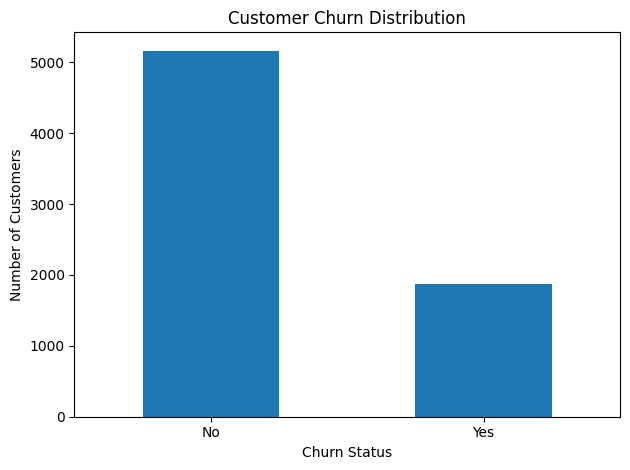

In [235]:
churn_counts.plot(
    kind="bar",
    title="Customer Churn Distribution"
)

plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [236]:
contract_analysis = pd.crosstab(
    clean_df["Contract"],
    clean_df["Churn"],
    normalize="index"
).mul(100).round(2)

contract_analysis

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


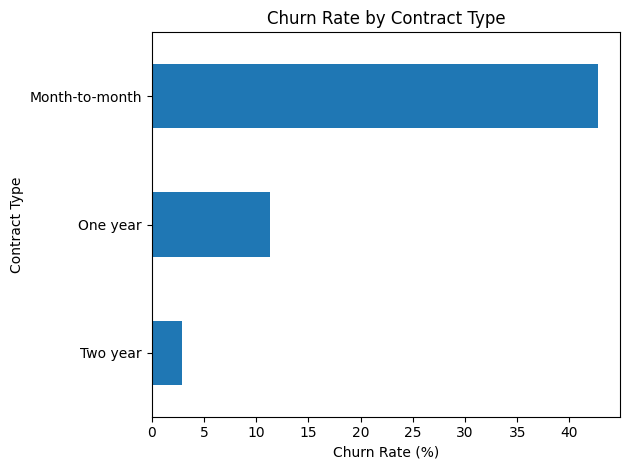

In [237]:
contract_analysis["Yes"].sort_values().plot(
    kind="barh",
    title="Churn Rate by Contract Type"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract Type")
plt.tight_layout()
plt.show()

In [238]:
internet_analysis = pd.crosstab(
    clean_df["InternetService"],
    clean_df["Churn"],
    normalize="index"
).mul(100).round(2)

internet_analysis

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


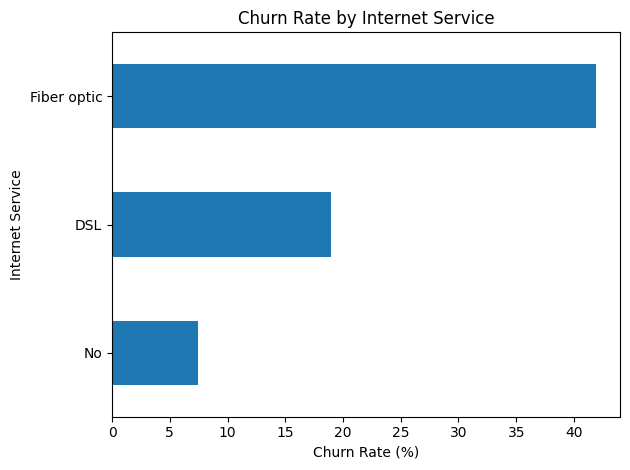

In [239]:
internet_analysis["Yes"].sort_values().plot(
    kind="barh",
    title="Churn Rate by Internet Service"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Internet Service")
plt.tight_layout()
plt.show()

In [240]:
payment_analysis = pd.crosstab(
    clean_df["PaymentMethod"],
    clean_df["Churn"],
    normalize="index"
).mul(100).round(2)

payment_analysis

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


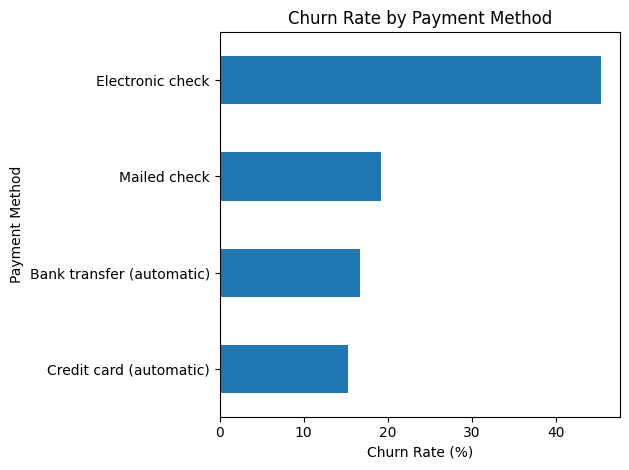

In [241]:
payment_analysis["Yes"].sort_values().plot(
    kind="barh",
    title="Churn Rate by Payment Method"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

In [242]:
tenure_analysis = pd.crosstab(
    clean_df["TenureGroup"],
    clean_df["Churn"],
    normalize="index"
).mul(100).round(2)

tenure_analysis

Churn,No,Yes
TenureGroup,,
0-12 Months,52.32,47.68
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-60 Months,85.58,14.42
61-72 Months,93.39,6.61


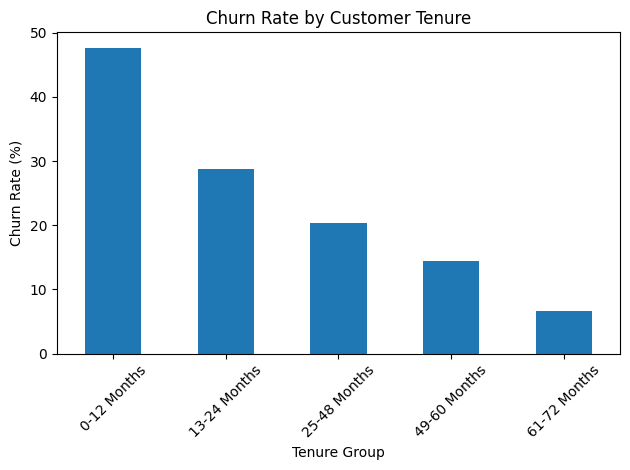

In [243]:
tenure_analysis["Yes"].plot(
    kind="bar",
    title="Churn Rate by Customer Tenure"
)

plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [244]:
monthly_charge_analysis = pd.crosstab(
    clean_df["MonthlyChargeGroup"],
    clean_df["Churn"],
    normalize="index"
).mul(100).round(2)

monthly_charge_analysis

Churn,No,Yes
MonthlyChargeGroup,,
Low,89.07,10.93
Medium,76.02,23.98
High,62.15,37.85
Very High,71.95,28.05


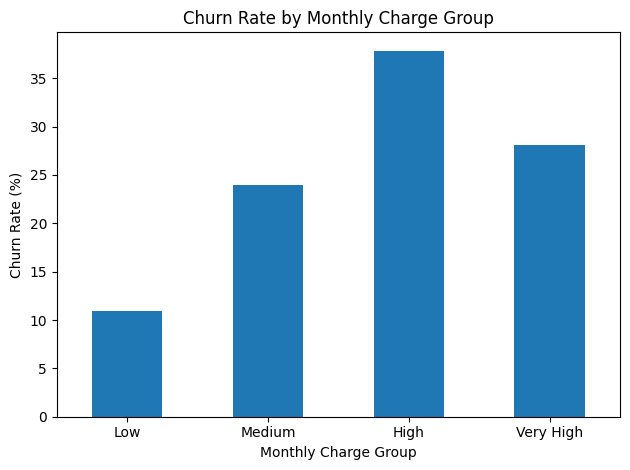

In [245]:
monthly_charge_analysis["Yes"].plot(
    kind="bar",
    title="Churn Rate by Monthly Charge Group"
)

plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [246]:
charge_comparison = clean_df.groupby("Churn")[
    ["MonthlyCharges", "TotalCharges", "tenure"]
].mean().round(2)

charge_comparison

,MonthlyCharges,TotalCharges,tenure
Churn,,,
No,61.31,2555.34,37.65
Yes,74.44,1531.80,17.98


## 5. SQL Customer Churn Analysis

In [247]:
connection = sqlite3.connect("customer_churn.db")

clean_df.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)

print("Customer churn database created successfully.")

Customer churn database created successfully.


In [248]:
query = """
SELECT *
FROM customers
LIMIT 5;
"""

pd.read_sql_query(query, connection)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,SeniorCitizenLabel,TenureGroup,MonthlyChargeGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,No,0-12 Months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,No,25-48 Months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,No,0-12 Months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,No,25-48 Months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,No,0-12 Months,High


In [249]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(ChurnFlag) AS churned_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate
FROM customers;
"""

pd.read_sql_query(query, connection)

,total_customers,churned_customers,churn_rate
0,7032,1869,26.58


In [250]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(ChurnFlag) AS churned_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

pd.read_sql_query(query, connection)

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


In [251]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(ChurnFlag) AS churned_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

pd.read_sql_query(query, connection)

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1604,308,19.20
2,Bank transfer (automatic),1542,258,16.73
3,Credit card (automatic),1521,232,15.25


In [252]:
query = """
SELECT
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    TotalCharges,
    PaymentMethod
FROM customers
WHERE ChurnFlag = 1
  AND TotalCharges > (
      SELECT AVG(TotalCharges)
      FROM customers
  )
ORDER BY TotalCharges DESC
LIMIT 20;
"""

pd.read_sql_query(query, connection)

,customerID,Contract,tenure,MonthlyCharges,TotalCharges,PaymentMethod
0,2889-FPWRM,One year,72,117.80,8684.80,Bank transfer (automatic)
1,0201-OAMXR,One year,70,115.55,8127.60,Credit card (automatic)
2,3886-CERTZ,One year,72,109.25,8109.80,Electronic check
3,1444-VVSGW,One year,70,115.65,7968.85,Credit card (automatic)
4,5271-YNWVR,Two year,68,113.15,7856.00,Electronic check
5,8199-ZLLSA,One year,67,118.35,7804.15,Bank transfer (automatic)
6,9053-JZFKV,Two year,67,116.20,7752.30,Credit card (automatic)
7,1555-DJEQW,Two year,70,114.20,7723.90,Bank transfer (automatic)
8,3259-FDWOY,Two year,71,106.00,7723.70,Bank transfer (automatic)
9,7317-GGVPB,Two year,71,108.60,7690.90,Credit card (automatic)


In [253]:
query = """
SELECT
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    TotalCharges,
    Churn,
    CASE
        WHEN Contract = 'Month-to-month'
             AND tenure <= 12
             AND MonthlyCharges >= 70
        THEN 'High Risk'

        WHEN Contract = 'Month-to-month'
             OR tenure <= 24
        THEN 'Medium Risk'

        ELSE 'Low Risk'
    END AS RiskSegment
FROM customers
ORDER BY TotalCharges DESC;
"""

risk_segments_df = pd.read_sql_query(query, connection)

risk_segments_df.head()

,customerID,Contract,tenure,MonthlyCharges,TotalCharges,Churn,RiskSegment
0,2889-FPWRM,One year,72,117.80,8684.80,Yes,Low Risk
1,7569-NMZYQ,Two year,72,118.75,8672.45,No,Low Risk
2,9739-JLPQJ,Two year,72,117.50,8670.10,No,Low Risk
3,9788-HNGUT,Two year,72,116.95,8594.40,No,Low Risk
4,8879-XUAHX,Two year,71,116.25,8564.75,No,Low Risk


## 6. Machine Learning Model Development

In [254]:
model_df = clean_df.drop(
    columns=[
        "customerID",
        "Churn",
        "ChurnFlag",
        "TenureGroup",
        "MonthlyChargeGroup",
        "SeniorCitizenLabel"
    ]
).copy()

In [255]:
X = model_df
y = clean_df["ChurnFlag"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7032, 19)
Target shape: (7032,)


In [256]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [257]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5625
Testing records: 1407


In [258]:
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)

In [259]:
OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [260]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [261]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=20,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

decision_tree_predictions = decision_tree_pipeline.predict(X_test)
decision_tree_probabilities = (
    decision_tree_pipeline.predict_proba(X_test)[:, 1]
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [262]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

random_forest_predictions = random_forest_pipeline.predict(X_test)
random_forest_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [263]:
def evaluate_model(
    model_name,
    actual,
    predictions,
    probabilities
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(actual, predictions),
        "Precision": precision_score(actual, predictions),
        "Recall": recall_score(actual, predictions),
        "F1 Score": f1_score(actual, predictions),
        "ROC-AUC": roc_auc_score(actual, probabilities)
    }

In [264]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

model_results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions,
        decision_tree_probabilities
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions,
        random_forest_probabilities
    )
)

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7257,0.4901,0.7968,0.6069,0.8351
1,Random Forest,0.7598,0.5349,0.7380,0.6202,0.8302
2,Decision Tree,0.7335,0.4992,0.7941,0.6130,0.8276


In [265]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Stayed", "Churned"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.90      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [266]:
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["Stayed", "Churned"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.89      0.77      0.82      1033
     Churned       0.53      0.74      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.76      0.77      1407



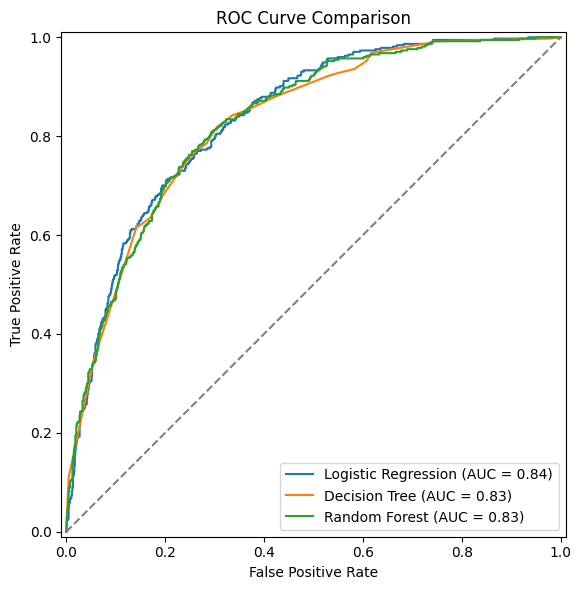

ROC curve saved successfully.


In [267]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    decision_tree_probabilities,
    name="Decision Tree",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probabilities,
    name="Random Forest",
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

plt.tight_layout()

plt.savefig(
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")

In [268]:
feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_values = (
    random_forest_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("numerical__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(15)

,Feature,Importance
0,tenure,0.126334
1,Contract_Month-to-month,0.126228
2,TotalCharges,0.103537
3,MonthlyCharges,0.073437
4,Contract_Two year,0.067382
5,OnlineSecurity_No,0.060995
6,TechSupport_No,0.049865
7,InternetService_Fiber optic,0.045553
8,PaymentMethod_Electronic check,0.035620
9,Contract_One year,0.019316


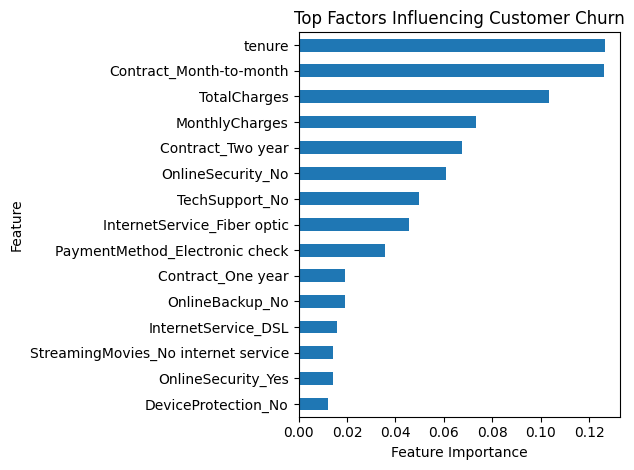

In [269]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

top_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    title="Top Factors Influencing Customer Churn"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [270]:
customer_features = clean_df[X.columns]

clean_df["PredictedChurn"] = logistic_pipeline.predict(
    customer_features
)

clean_df["ChurnProbability"] = logistic_pipeline.predict_proba(
    customer_features
)[:, 1]

In [271]:
clean_df["RiskLevel"] = pd.cut(
    clean_df["ChurnProbability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    include_lowest=True
)

In [272]:
clean_df[
    [
        "customerID",
        "Churn",
        "PredictedChurn",
        "ChurnProbability",
        "RiskLevel"
    ]
].head(10)

,customerID,Churn,PredictedChurn,ChurnProbability,RiskLevel
0,7590-VHVEG,No,1,0.809656,High Risk
1,5575-GNVDE,No,0,0.116409,Low Risk
2,3668-QPYBK,Yes,1,0.515596,Medium Risk
3,7795-CFOCW,No,0,0.081040,Low Risk
4,9237-HQITU,Yes,1,0.852570,High Risk
5,9305-CDSKC,Yes,1,0.911660,High Risk
6,1452-KIOVK,No,1,0.723692,High Risk
7,6713-OKOMC,No,1,0.564519,Medium Risk
8,7892-POOKP,Yes,1,0.814708,High Risk
9,6388-TABGU,No,0,0.029970,Low Risk


In [273]:
def recommend_action(row):
    if row["RiskLevel"] == "High Risk":
        if row["Contract"] == "Month-to-month":
            return "Offer discounted annual contract"

        if row["TechSupport"] == "No":
            return "Offer free technical support trial"

        return "Immediate retention outreach"

    if row["RiskLevel"] == "Medium Risk":
        return "Send personalized loyalty offer"

    return "Maintain regular engagement"


clean_df["RecommendedAction"] = clean_df.apply(
    recommend_action,
    axis=1
)

In [274]:
clean_df[
    [
        "customerID",
        "RiskLevel",
        "Contract",
        "TechSupport",
        "RecommendedAction"
    ]
].head(10)

,customerID,RiskLevel,Contract,TechSupport,RecommendedAction
0,7590-VHVEG,High Risk,Month-to-month,No,Offer discounted annual contract
1,5575-GNVDE,Low Risk,One year,No,Maintain regular engagement
2,3668-QPYBK,Medium Risk,Month-to-month,No,Send personalized loyalty offer
3,7795-CFOCW,Low Risk,One year,Yes,Maintain regular engagement
4,9237-HQITU,High Risk,Month-to-month,No,Offer discounted annual contract
5,9305-CDSKC,High Risk,Month-to-month,No,Offer discounted annual contract
6,1452-KIOVK,High Risk,Month-to-month,No,Offer discounted annual contract
7,6713-OKOMC,Medium Risk,Month-to-month,No,Send personalized loyalty offer
8,7892-POOKP,High Risk,Month-to-month,Yes,Offer discounted annual contract
9,6388-TABGU,Low Risk,One year,No,Maintain regular engagement


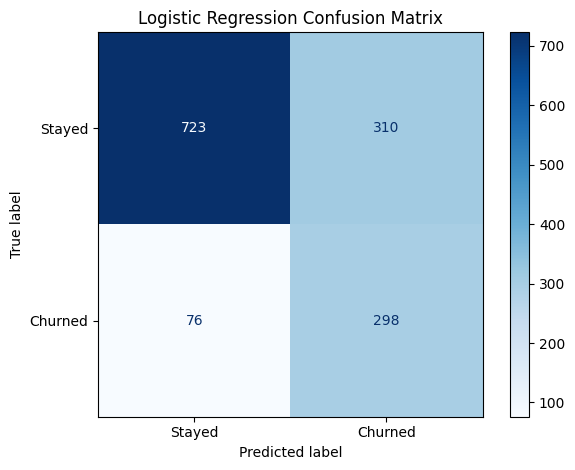

Confusion matrix saved successfully.
Location: images/confusion_matrix.png


In [275]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Stayed", "Churned"],
    values_format="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully.")
print("Location: images/confusion_matrix.png")

In [276]:
clean_df.to_csv(
    "customer_churn_powerbi.csv",
    index=False
)

results_df.to_csv(
    "model_performance.csv",
    index=False
)

feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

kpi_df.to_csv(
    "kpi_summary.csv",
    index=False
)

print("Power BI files exported successfully.")

Power BI files exported successfully.


In [277]:
from google.colab import files

files.download("customer_churn_powerbi.csv")
files.download("model_performance.csv")
files.download("feature_importance.csv")
files.download("kpi_summary.csv")
files.download("customer_churn.db")
files.download("confusion_matrix.png")
files.download("roc_curve_comparison.png")
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>